# ex-2 v2 — mono, composed on `fl_plot` (modern API remake)

The ex-2 v2 figure set rebuilt entirely from `fl_plot` marks — no fl_graphics helpers, no
local plotting functions. Mono treatment throughout (gray boxes, factor identity via hatching, bare
measured dots), with a **component-colored** section at the end (box color = quantity,
matching the band fills). Data loads from the shared `ex2v2_df_{p,n}.parquet` cache; this
notebook is composition-only — regenerate the cache with `ex-2_heavy_tail_v2` (root) or
its mono duplicate if missing. Figures → `nb_outputs/mono-ex2v2-flplot/`.

| legacy figure | composition here |
|---|---|
| five-row decomposition | `Row(BandStack)` + four `Row(BoxDist)` |
| component two-rows (1–4) | `Row([Band, MeanCI])` + `Row(BoxDist)` |
| rotation (Q1–Q3 view) | `Row([QuantileBand, MeanCI])` + `Row(BoxDist)` |
| in-subspace rotation dist | `Row([BoxDist, RefOverlay])` |

In [32]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_plot import (grid, Row, BandStack, Band, MeanCI, QuantileBand, BoxDist,
                     RefOverlay, Theme, THEME)

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = REPO_ROOT / "nb_outputs" / "ex2v2-flplot"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_FORMATS = ("pdf",)
SAVE_FIGS = False   # default: figures are NOT written to disk; enable one with out(..., save=True)


def out(stem, save=None):
    """out_path for grid(): OUT_DIR/stem when saving is on (globally via
    SAVE_FIGS, or per-figure via save=True), else None."""
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None


FACTOR_HATCHES = ("", "//", "xx", "..", "\\\\", "++")   # per-factor identity, colorless
MONO_THEME = Theme(factor_colors=("tab:gray",) * 6, factor_cmaps=("Greys",) * 6,
                   factor_hatches=FACTOR_HATCHES,
                   ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


def derive(df):
    """Theory limits + pathwise differences, from the recorded columns."""
    oos = df["measured_out_of_subspace"]
    return df.assign(
        theory_insub=df["rhs"] - df["floor"],
        gap=df["rhs"] - df["sin2_j"],
        diff_oos=df["floor"] - oos,
        diff_insub=(df["rhs"] - df["floor"]) - df["measured_in_subspace"],
        sin2_in=(df["sin2_j"] - oos) / (1.0 - oos),
    )


In [33]:
# ── Sweep machinery, carried verbatim from ex-2 v2 / ex-3 (no .py files touched) ──
# Generates (or loads) the shared nb_outputs/ex2v2_df_{p,n}.parquet cache: same model,
# designs, and seed as ex-2/ex-3, so the replicates are identical across notebooks.
from fl_experiment_setup import ModelSpec, DesignSpec, BaseExperiment
from fl_experiment_runner import run_experiment
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment

# Canonical diagonal-Gram model (factor 1 market-like, c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511

design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)


class ObservableSpectrumAnalysis:
    """Observable side of Corollary 1: eigendecompose the n×n Gram G = Y^T Y, keep the full
    spectrum for the bulk average ℓ, and the top-k spikes θ_j (dual rescaled by 1/(n·p))."""

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        p, n = Y.shape
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        order = np.argsort(eigenvalues)[::-1]
        top_k = order[:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)   # (p, k)
        sin2_angle, dist_sine = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)

        dual = eigenvalues[order] / (n * p)
        theta = dual[:k]
        bulk = dual[k:n - 1] if self.center else dual[k:]
        ell = float(bulk.mean())
        return {"sin2_j": sin2_angle, "dist_sine": dist_sine,
                "sample_spike_eigenvalues_theta": theta,
                "sample_bulk_eigenvalue_average_ell": ell,
                "observable_floor_estimate": ell / theta}


class ObservableFloorExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [ObservableSpectrumAnalysis(b_pop, center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        gap = merged["sin2_j"] - merged["rhs"]
        return [
            {"n": n, "p": p, "j": j + 1,
             "sin2_j": float(merged["sin2_j"][j]), "rhs": float(merged["rhs"][j]),
             "gap": float(gap[j]), "floor": float(merged["floor"][j]),
             "rotation": float(merged["rotation"][j]), "rho": float(merged["rhos"][j]),
             "theta_j_sample_eigenvalue": float(merged["sample_spike_eigenvalues_theta"][j]),
             "ell_bulk_eigenvalue_average": float(merged["sample_bulk_eigenvalue_average_ell"]),
             "observable_floor_estimate": float(merged["observable_floor_estimate"][j])}
            for j in range(k)]


class MeasuredDecompositionAnalysis(ObservableSpectrumAnalysis):
    """Adds the finite-p eq.(18) split: ‖Π⊥h_j‖² via projection of h_j onto col(b_pop)."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        top_k = np.argsort(eigenvalues)[::-1][:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)
        coeffs = self.population_loading_directions_b_pop @ H           # (k, k)
        in_subspace = (coeffs ** 2).sum(axis=0)
        result["measured_out_of_subspace"] = 1.0 - in_subspace          # ‖Π⊥h_j‖²
        result["measured_in_subspace"] = result["sin2_j"] - (1.0 - in_subspace)
        result["angle_in_subspace"] = np.arccos(np.abs(np.diag(coeffs)) / np.sqrt(in_subspace))     # ∠(Π h_j, b_j), radians

        return result


class MeasuredDecompositionExperiment(ObservableFloorExperiment):
    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [MeasuredDecompositionAnalysis(b_pop, center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        rows = super().record(n, p, merged)
        for j, row in enumerate(rows):
            row["measured_out_of_subspace"] = float(merged["measured_out_of_subspace"][j])
            row["measured_in_subspace"] = float(merged["measured_in_subspace"][j])
            row["angle_in_subspace"] = float(merged["angle_in_subspace"][j])

        return rows


_pq_p, _pq_n = DATA_DIR / "ex2v2_df_p.parquet", DATA_DIR / "ex2v2_df_n.parquet"
if _pq_p.exists() and _pq_n.exists():
    df_p, df_n = pd.read_parquet(_pq_p), pd.read_parquet(_pq_n)
    print("loaded cached ex2v2 sweeps")
else:
    print("ex2v2 sweep cache missing — running sweeps (takes a few minutes)...")
    df_p = run_experiment(model, design_p, MeasuredDecompositionExperiment(), progress=True)
    df_n = run_experiment(model, design_n, MeasuredDecompositionExperiment(), progress=True)
    df_p.to_parquet(_pq_p)
    df_n.to_parquet(_pq_n)

df_p, df_n = derive(df_p), derive(df_n)
_SWEEPS = [(df_p, "p", "growing p, fixed n=63"), (df_n, "n", "growing n, fixed p=3000")]

# eq.(18) sanity, per replicate
for d, key, lab in _SWEEPS:
    recon = d["measured_out_of_subspace"] + d["measured_in_subspace"]
    print(f"{lab}: max |sin2_j − (oos + insub)| = {(d['sin2_j'] - recon).abs().max():.2e}")

loaded cached ex2v2 sweeps
growing p, fixed n=63: max |sin2_j − (oos + insub)| = 0.00e+00
growing n, fixed p=3000: max |sin2_j − (oos + insub)| = 0.00e+00


## Five-row decomposition

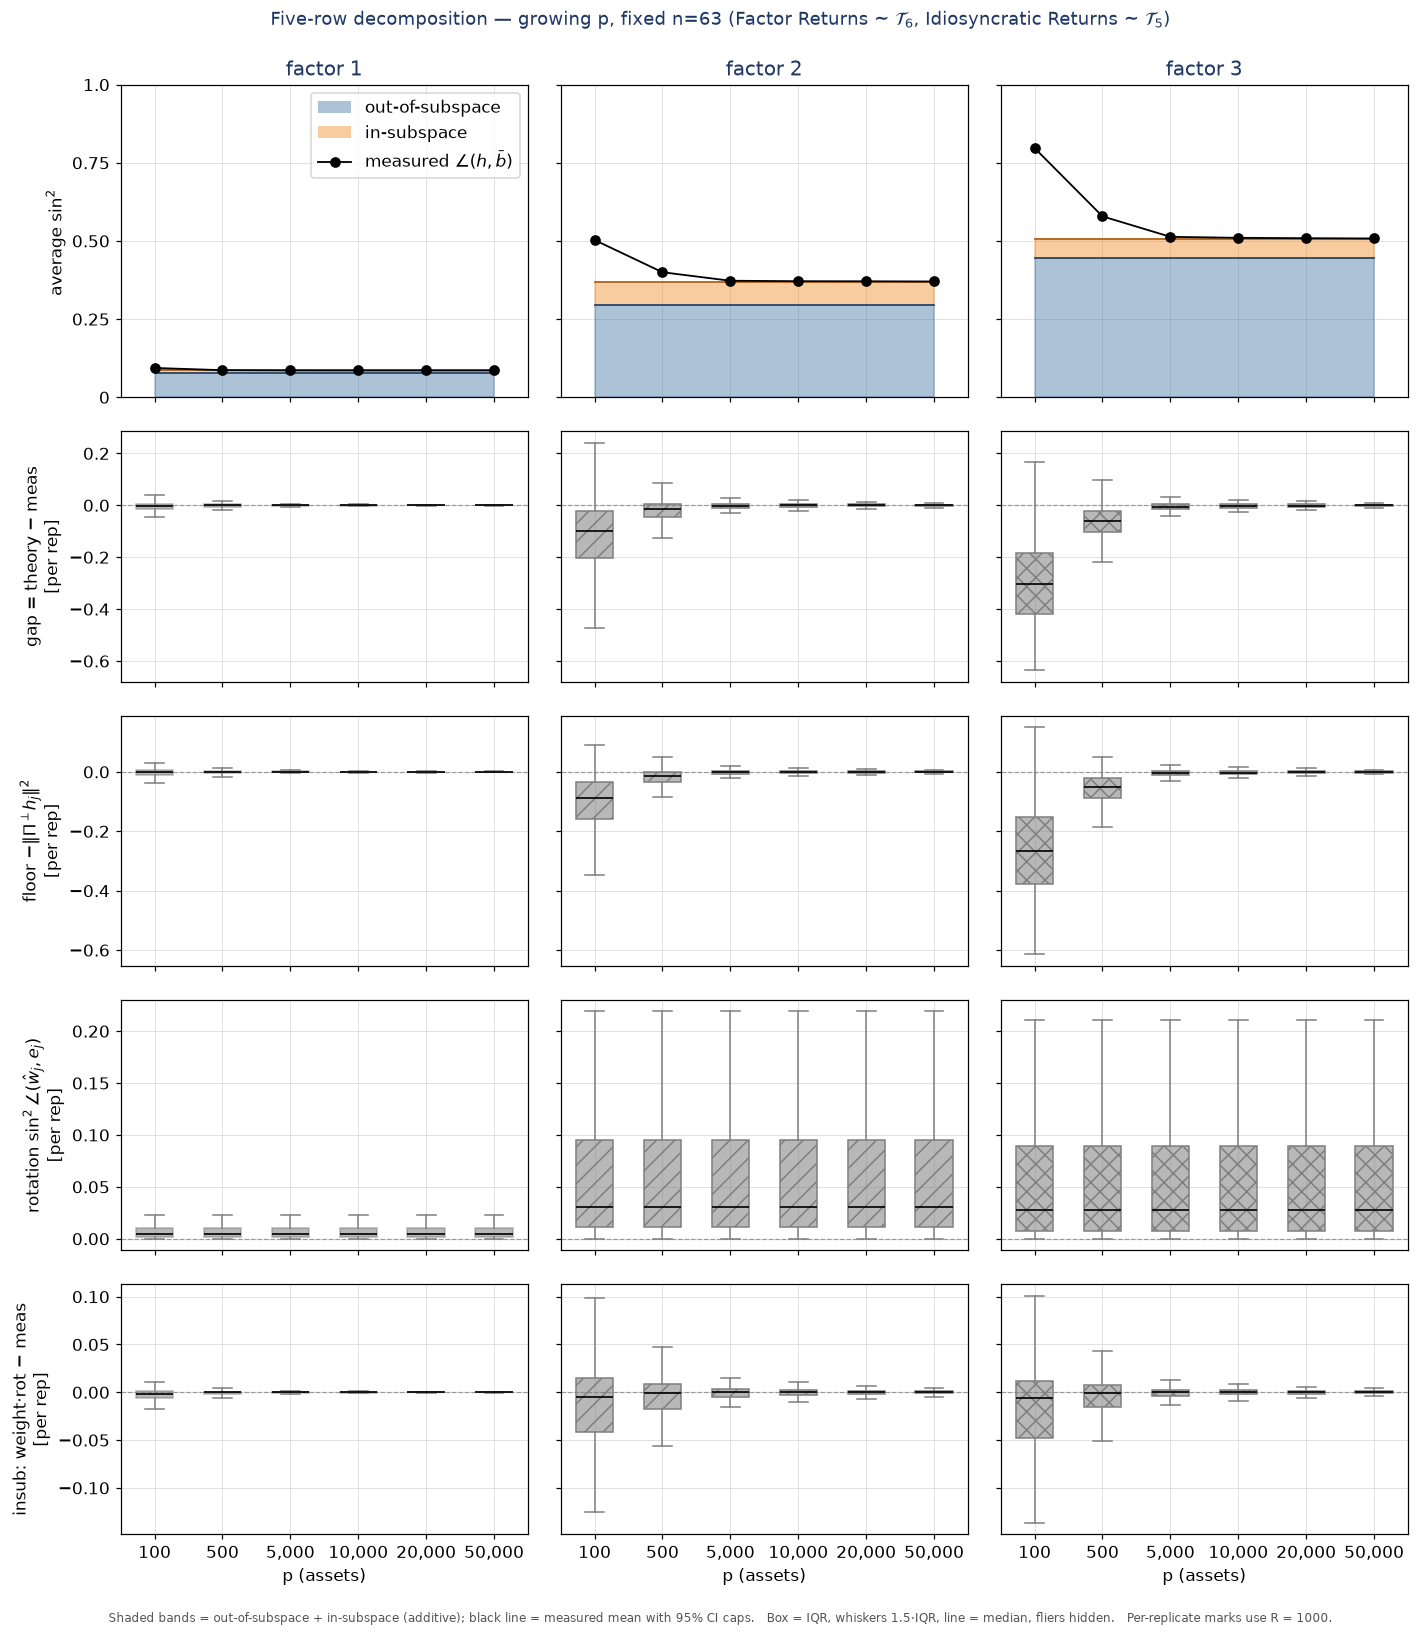

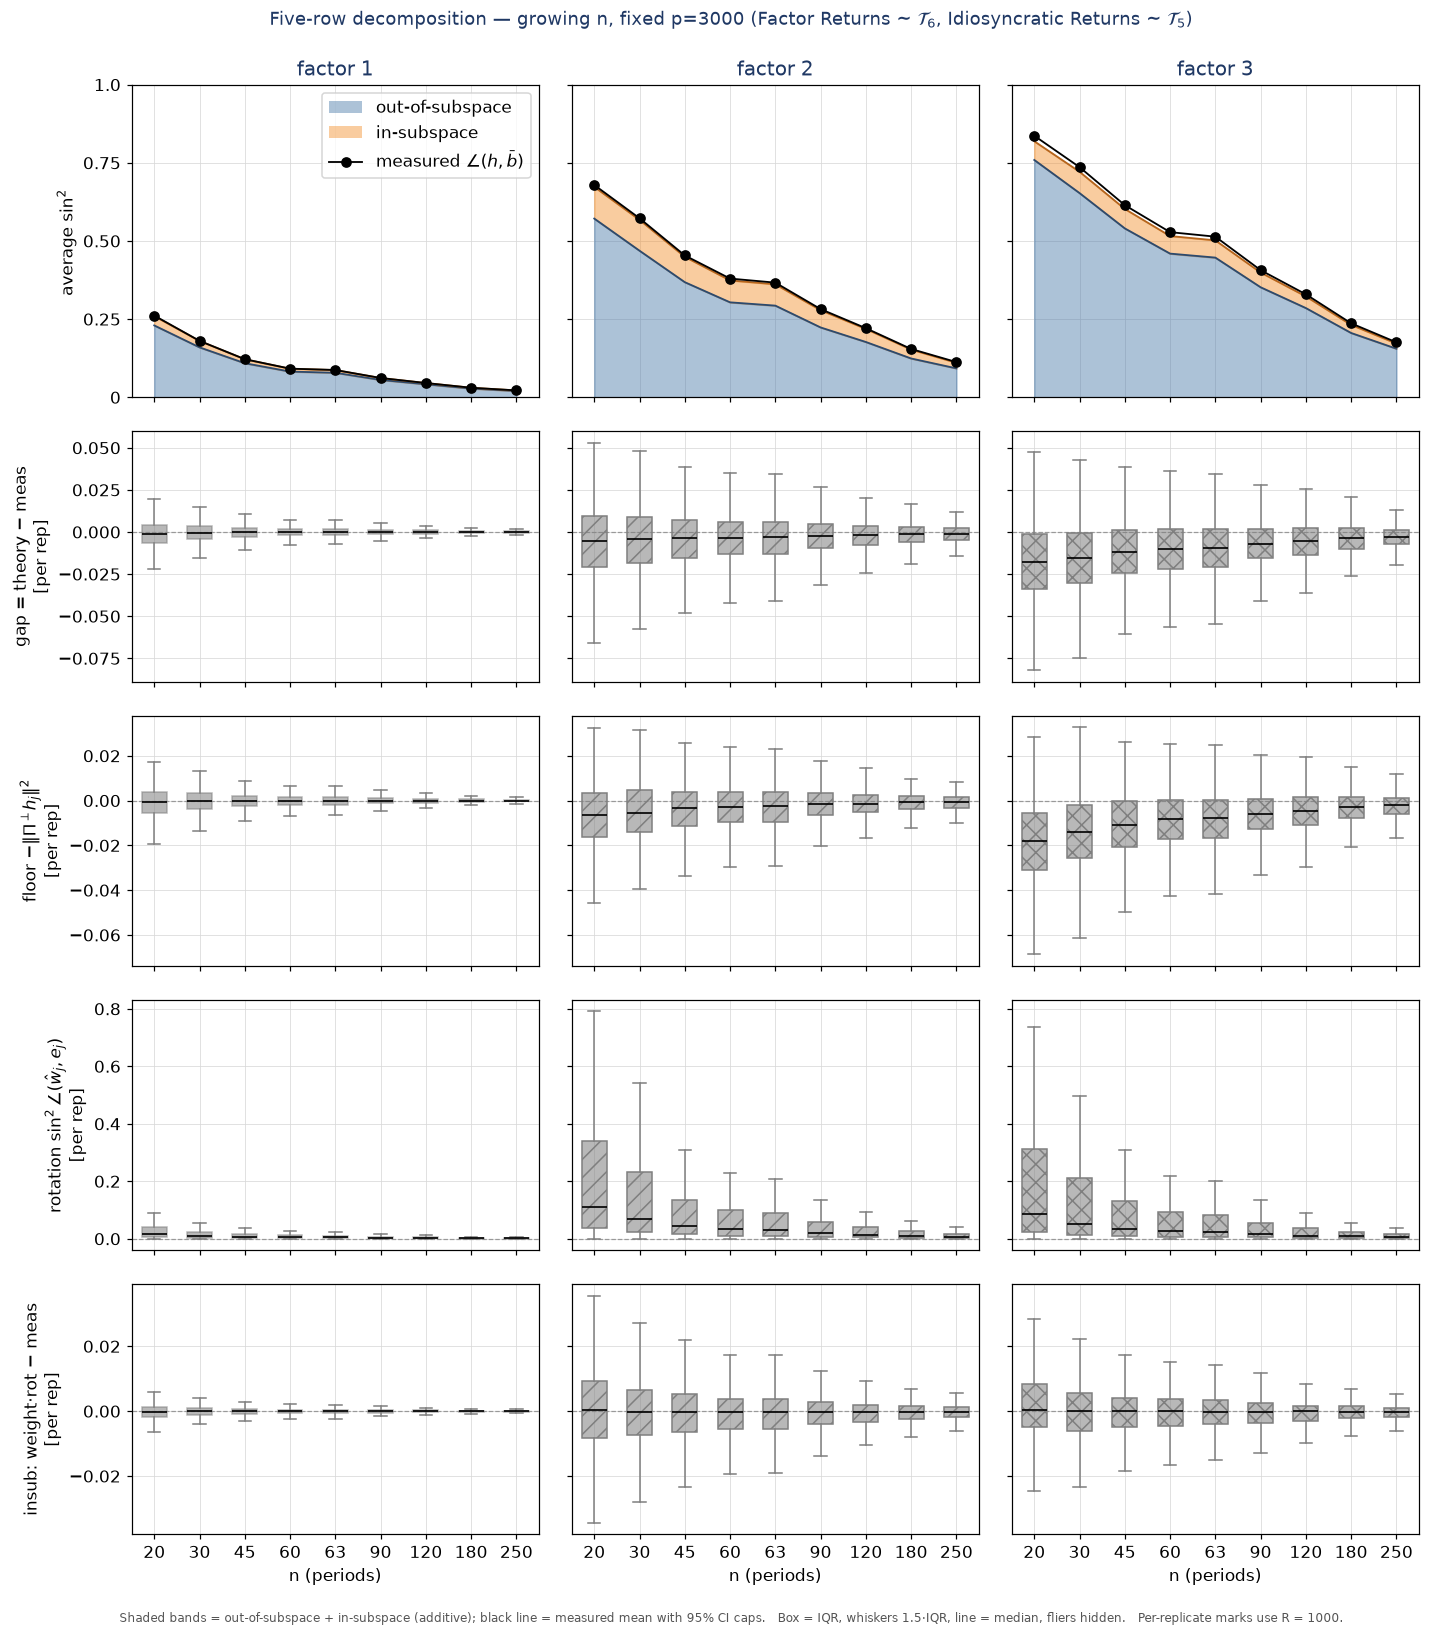

In [34]:
for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key,
        rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
                                    r"measured $\angle(h,\bar b)$")),
                  ylabel=r"average $\sin^2$", ylim=(0, 1),
                  yticks=THEME.sin2_ticks, height=1.0),
              Row(BoxDist("gap"), ylabel="gap = theory − meas\n[per rep]"),
              Row(BoxDist("diff_oos"),
                  ylabel=r"floor $- \Vert\Pi^{\perp}h_j\Vert^2$" + "\n[per rep]"),
              Row(BoxDist("rotation"),
                  ylabel=r"rotation $\sin^2\angle(\hat w_j, e_j)$" + "\n[per rep]"),
              Row(BoxDist("diff_insub"),
                  ylabel=r"insub: weight$\cdot$rot $-$ meas" + "\n[per rep]")],
        theme=MONO_THEME,
        suptitle=f"Five-row decomposition — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_fiverow_{key}"))
    show(fig)

## Broken-out component figures

Total, out-of-subspace, rotation, in-subspace — each a band/limit top row over a pathwise
boxplot row, per sweep.

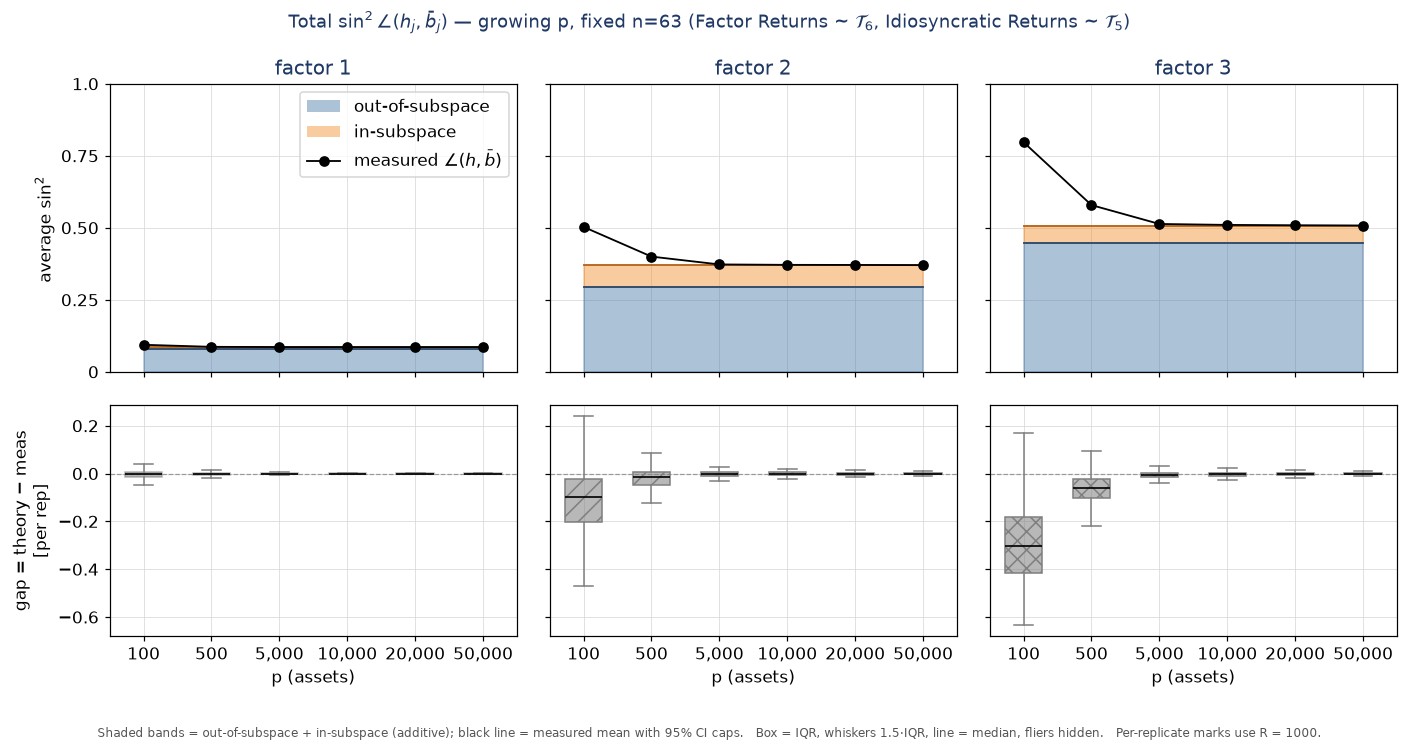

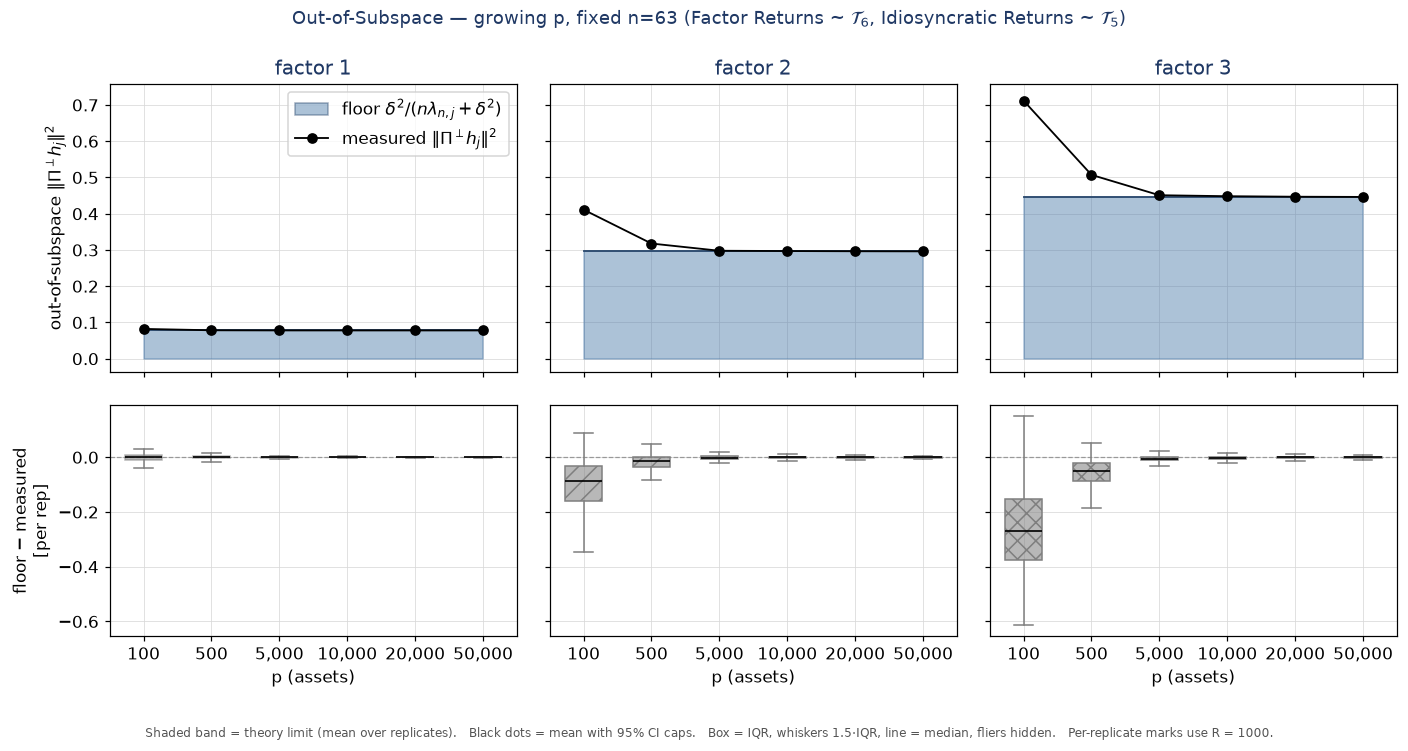

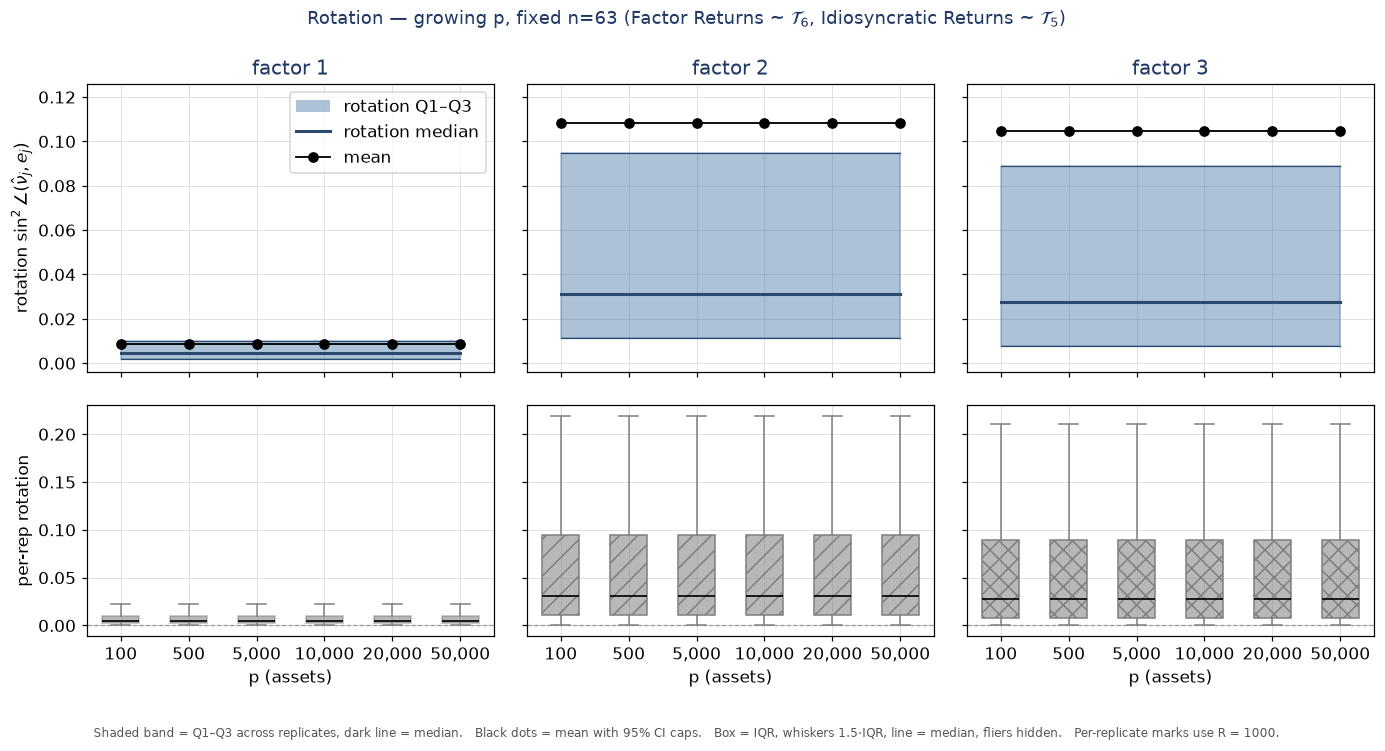

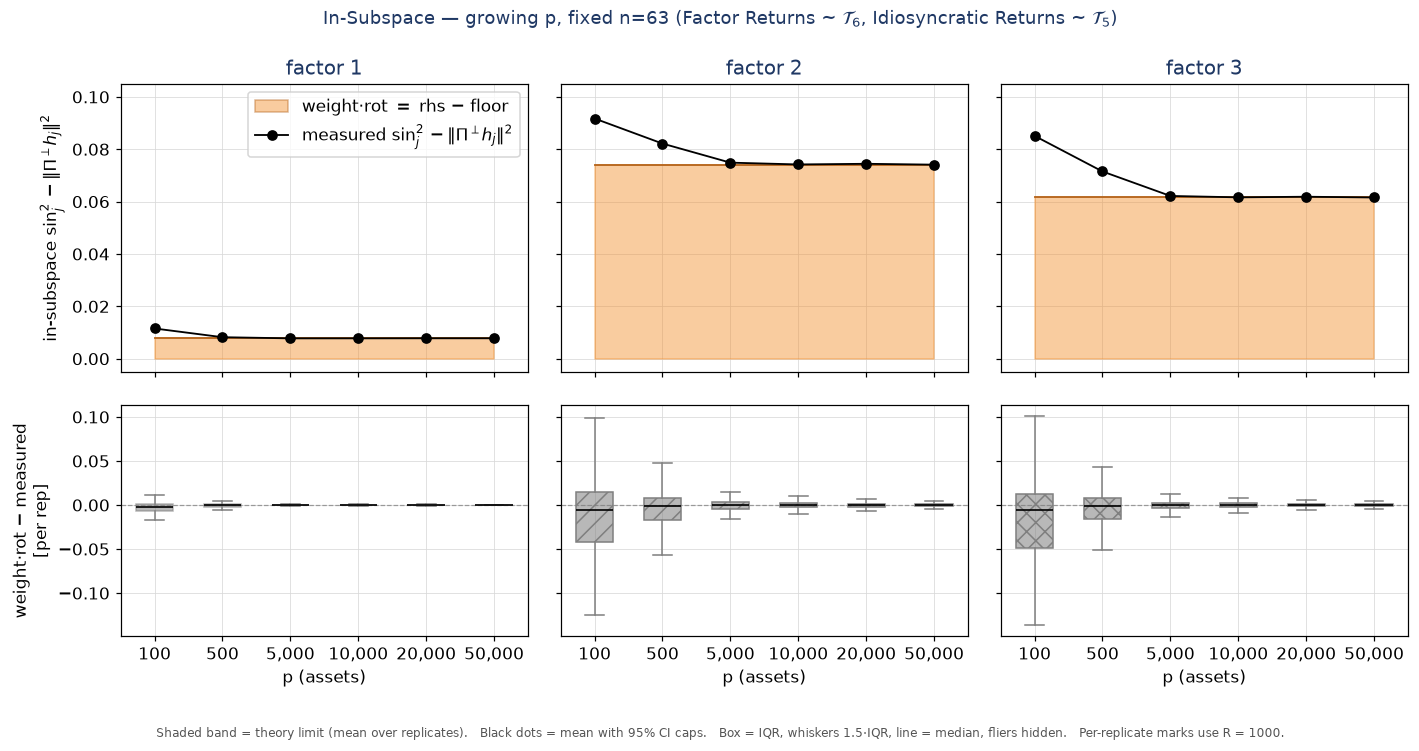

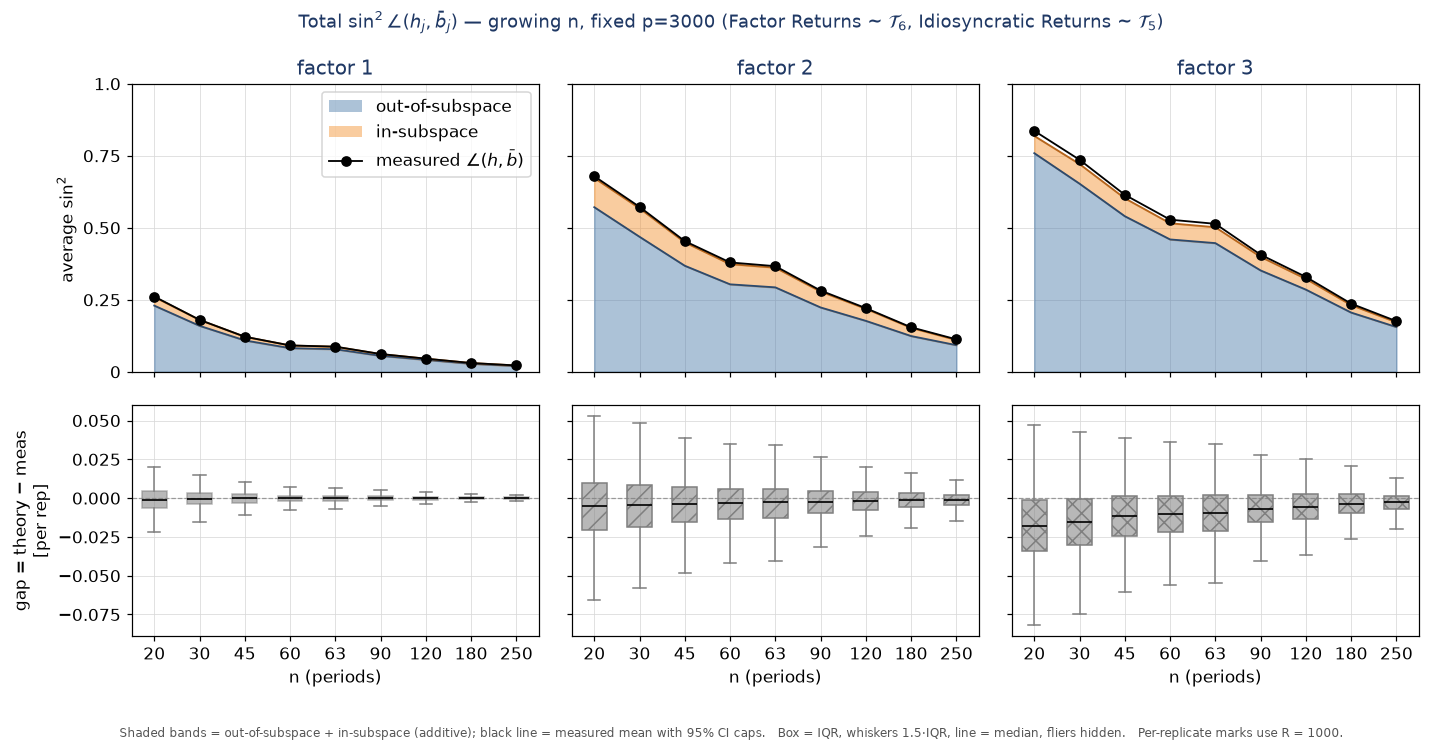

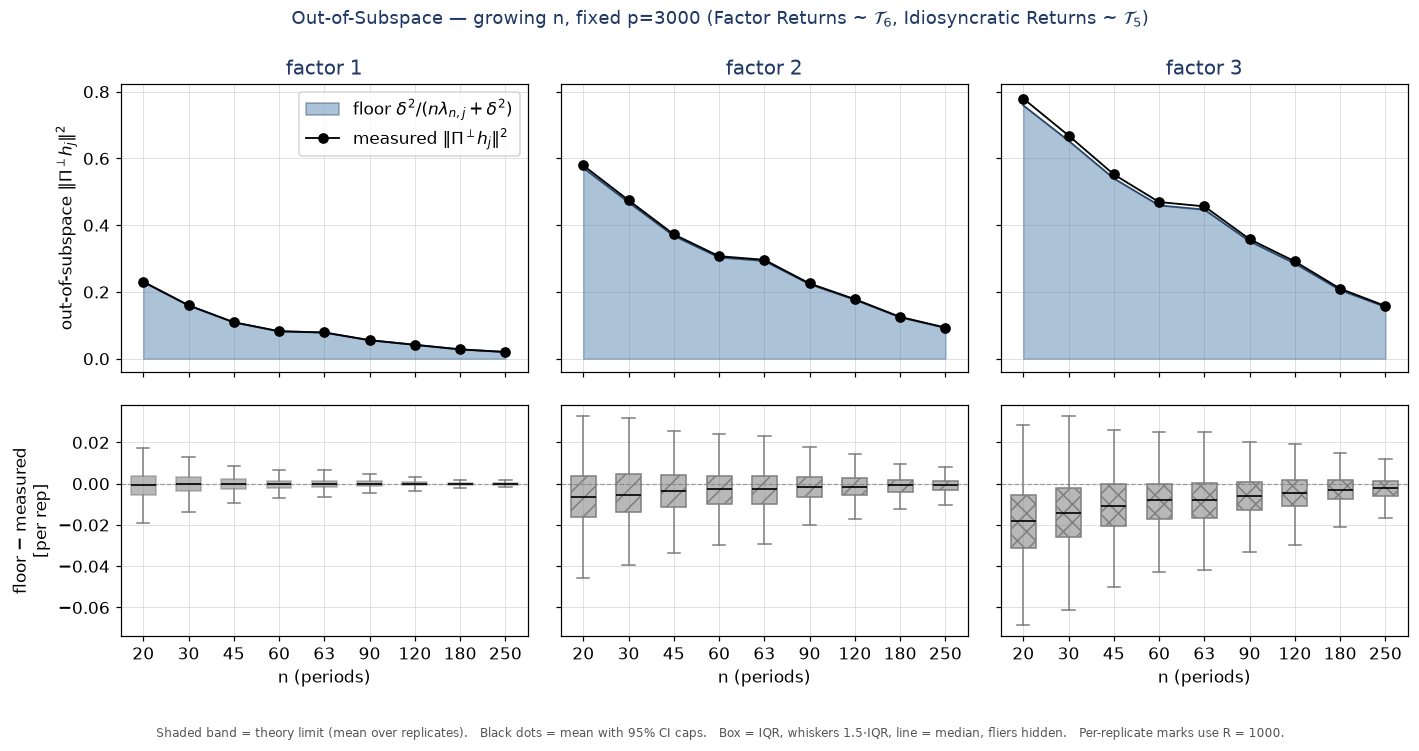

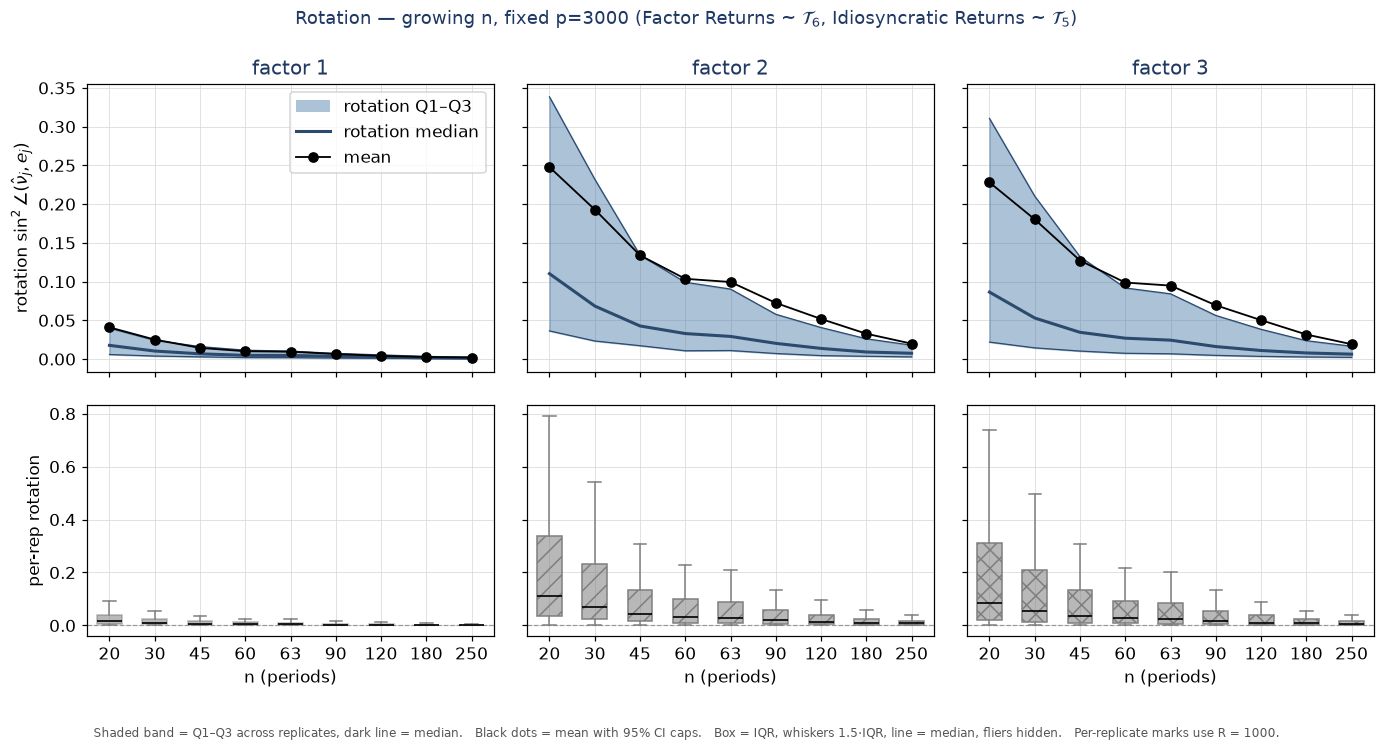

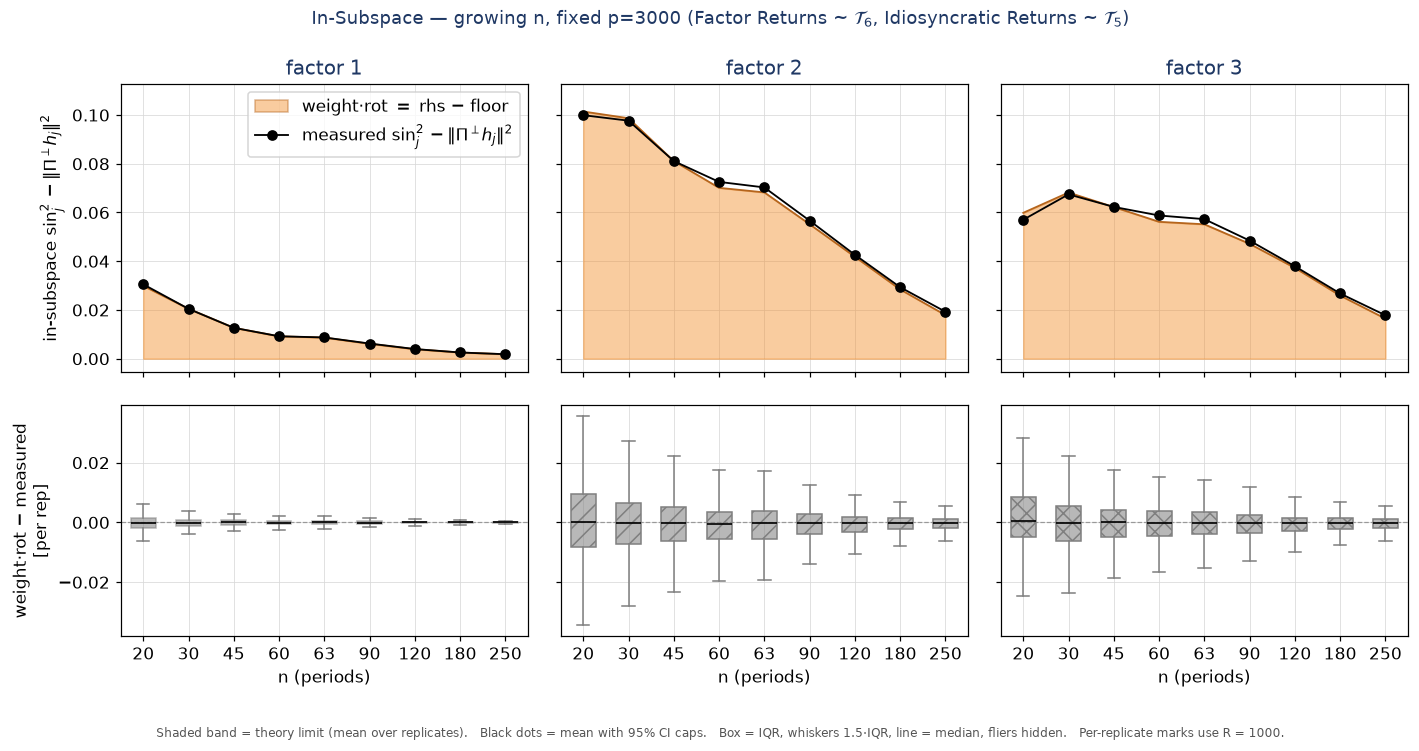

In [35]:
for d, key, lab in _SWEEPS:
    # 1 — total
    fig, _ = grid(d, key,
        rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
                                    r"measured $\angle(h,\bar b)$")),
                  ylabel=r"average $\sin^2$", ylim=(0, 1),
                  yticks=THEME.sin2_ticks, height=1.0),
              Row(BoxDist("gap"), ylabel="gap = theory − meas\n[per rep]")],
        theme=MONO_THEME,
        suptitle=rf"Total $\sin^2\angle(h_j,\bar b_j)$ — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp1_total_{key}"))
    show(fig)
    # 2 — out-of-subspace
    fig, _ = grid(d, key,
        rows=[Row([Band("floor", label=r"floor $\delta^2/(n\lambda_{n,j}+\delta^2)$"),
                   MeanCI("measured_out_of_subspace",
                          label=r"measured $\Vert\Pi^{\perp}h_j\Vert^2$")],
                  ylabel=r"out-of-subspace $\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
              Row(BoxDist("diff_oos"), ylabel="floor − measured\n[per rep]")],
        theme=MONO_THEME,
        suptitle=rf"Out-of-Subspace — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp2_oos_{key}"))
    show(fig)
    # 3 — rotation (a measured level: Q1–Q3 distribution view, no theory pair)
    fig, _ = grid(d, key,
        rows=[Row([QuantileBand("rotation", label="rotation"),
                   MeanCI("rotation", label="mean")],
                  ylabel=r"rotation $\sin^2\angle(\hat\nu_j, e_j)$", height=1.0),
              Row(BoxDist("rotation"), ylabel="per-rep rotation")],
        theme=MONO_THEME,
        suptitle=rf"Rotation — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp3_rotation_{key}"))
    show(fig)
    # 4 — in-subspace
    fig, _ = grid(d, key,
        rows=[Row([Band("theory_insub", label=r"weight$\cdot$rot $=$ rhs $-$ floor",
                        fill=THEME.insub_fill, line=THEME.insub_line),
                   MeanCI("measured_in_subspace",
                          label=r"measured $\sin^2_j - \Vert\Pi^{\perp}h_j\Vert^2$")],
                  ylabel=r"in-subspace $\sin^2_j-\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
              Row(BoxDist("diff_insub"), ylabel="weight·rot − measured\n[per rep]")],
        theme=MONO_THEME,
        suptitle=rf"In-Subspace — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp4_insub_{key}"))
    show(fig)

## In-subspace rotation distribution (limit overlaid)

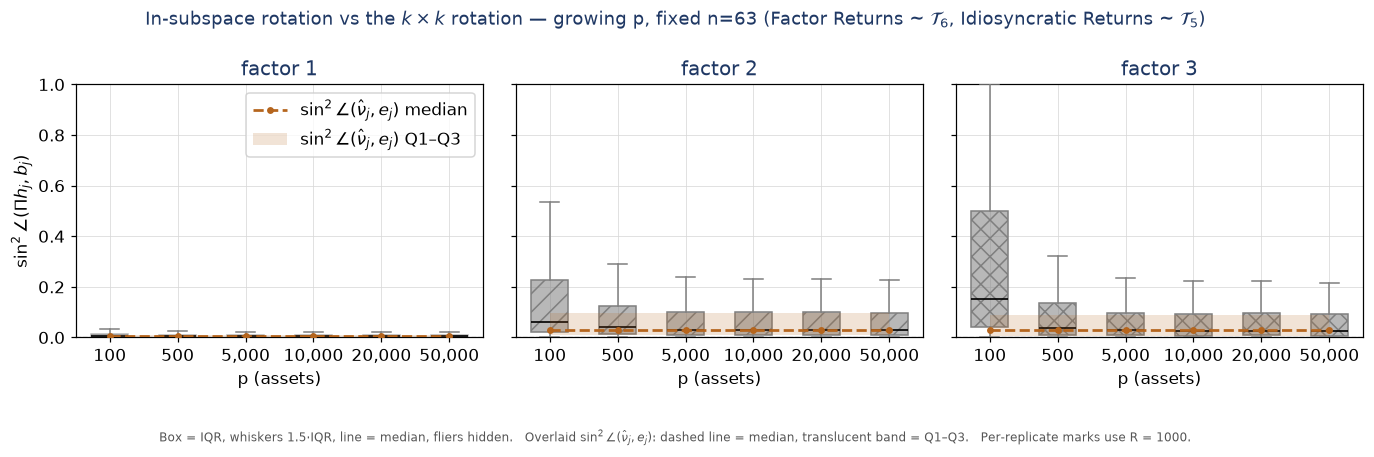

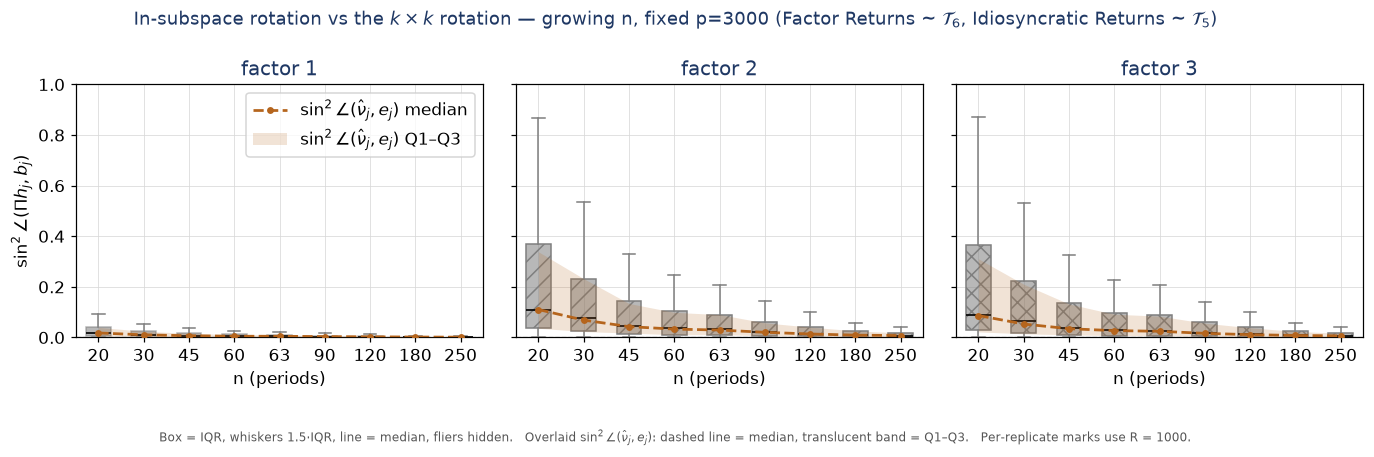

In [36]:
for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key,
        rows=[Row([BoxDist("sin2_in"),
                   RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$")],
                  ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
        sharey=True, theme=MONO_THEME,
        suptitle=f"In-subspace rotation vs the $k\\times k$ rotation — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_insub_rotation_{key}"))
    show(fig)

---
## Component-colored versions

Box color = quantity, matching the band fills: total gray, out-of-subspace blue,
rotation green, in-subspace orange.

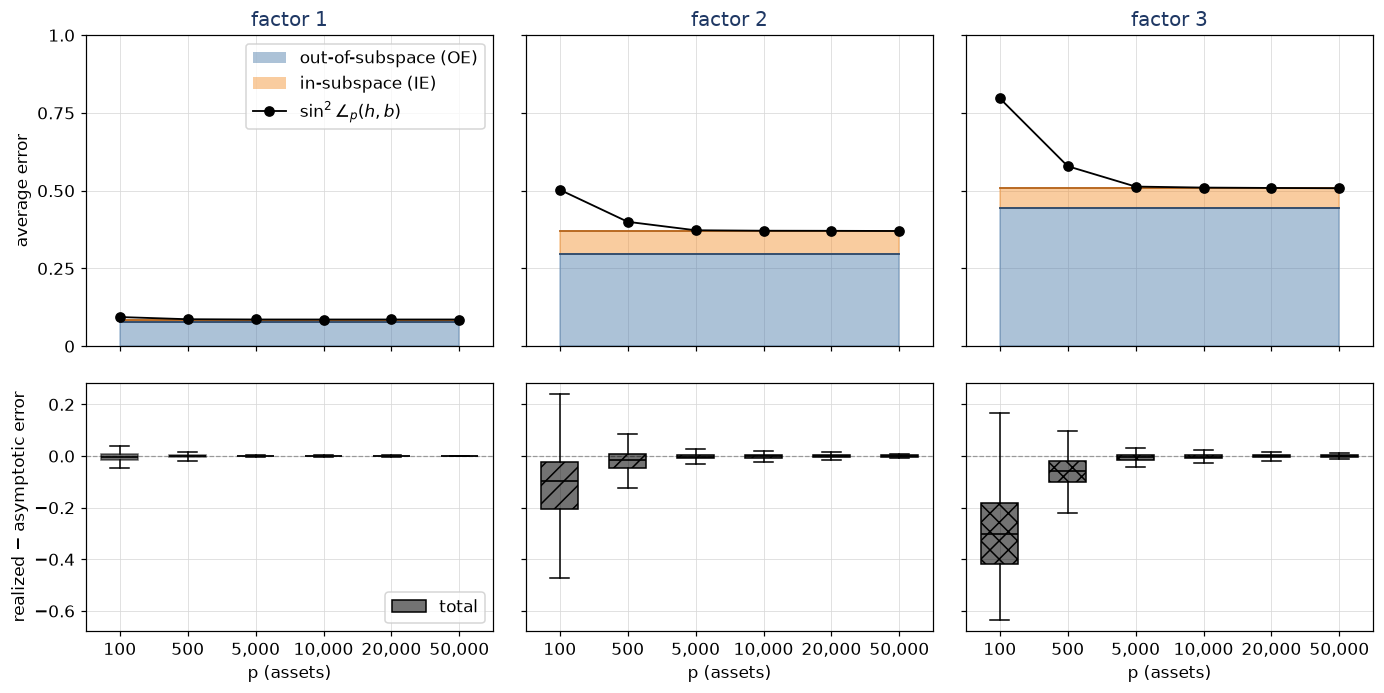

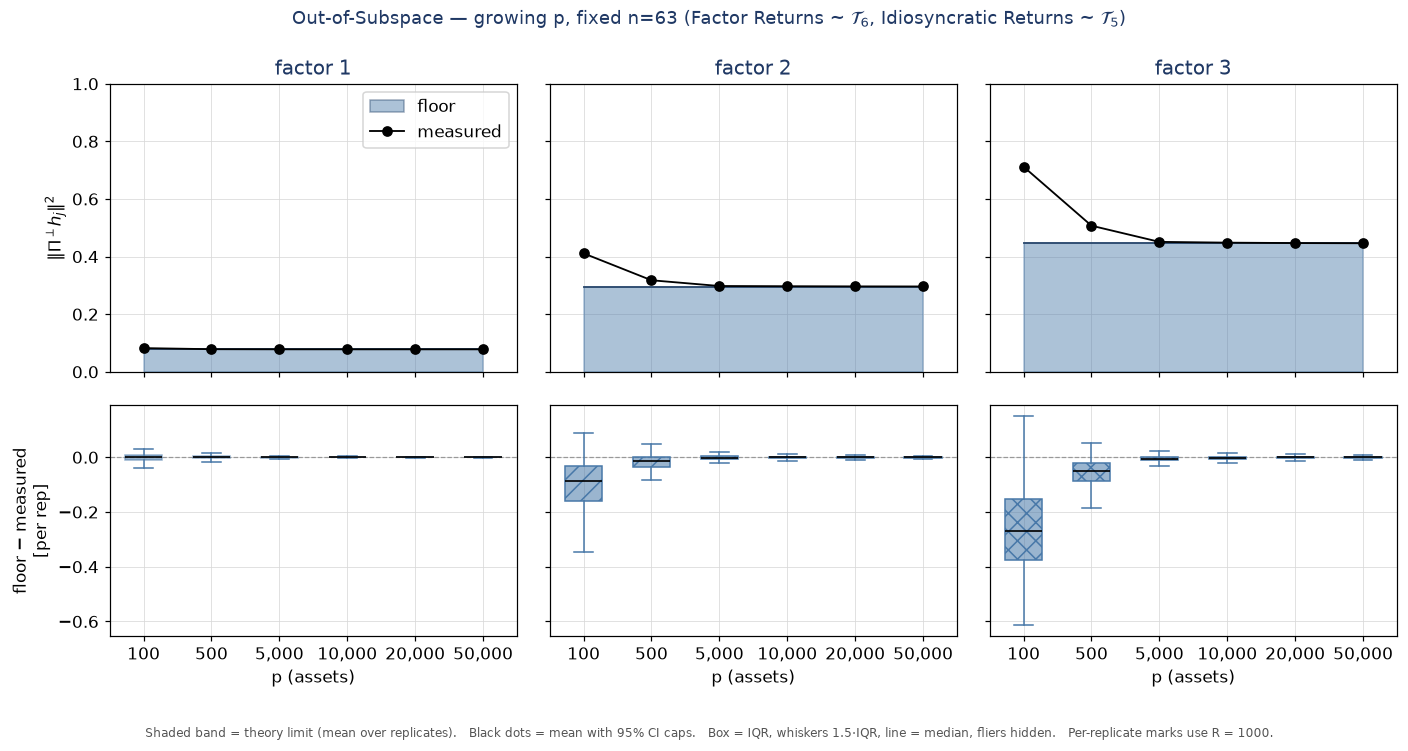

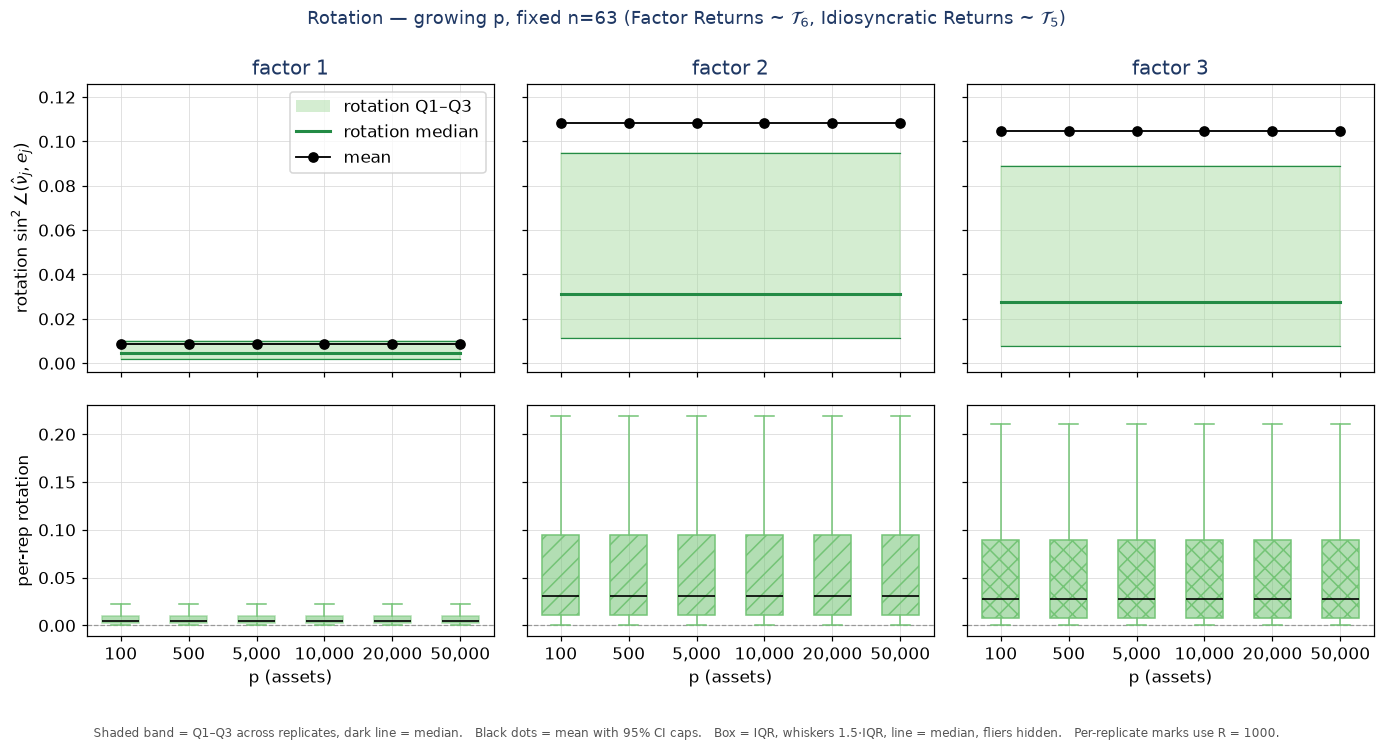

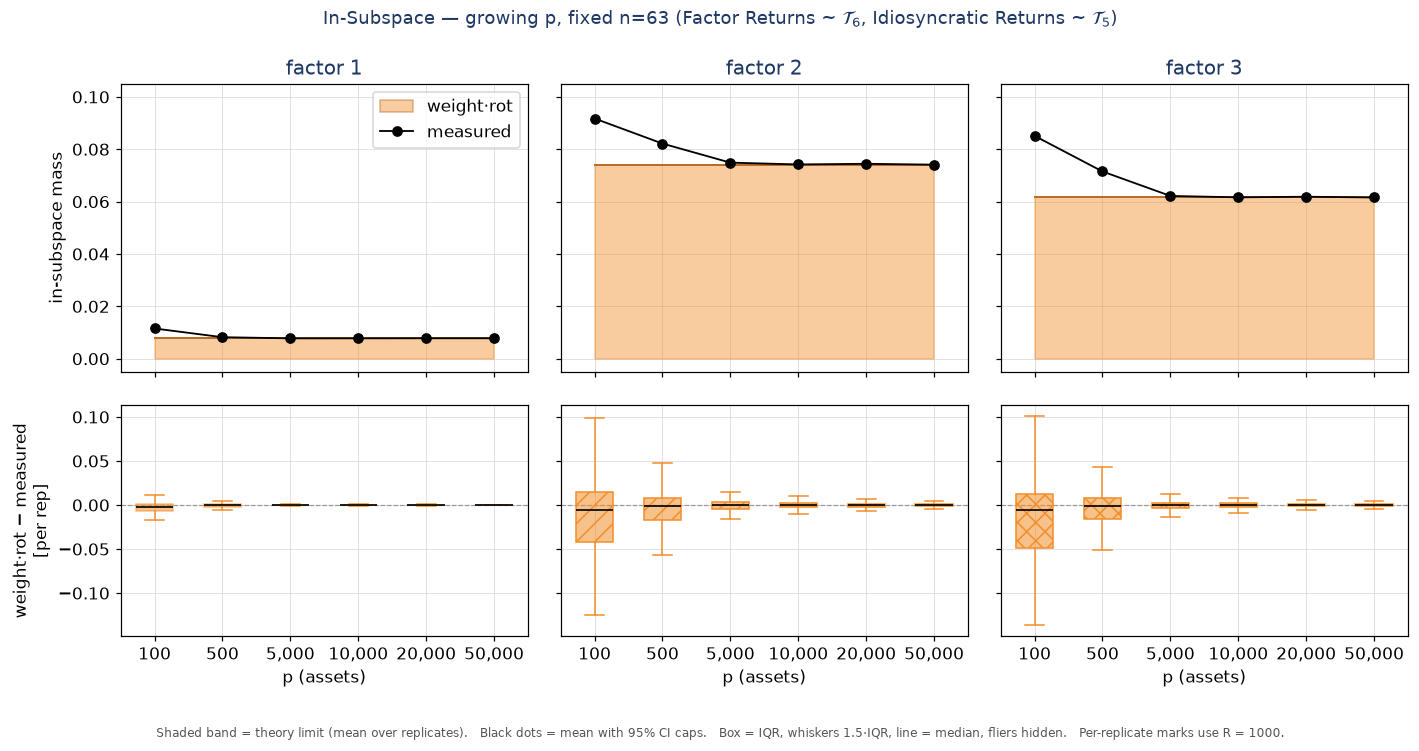

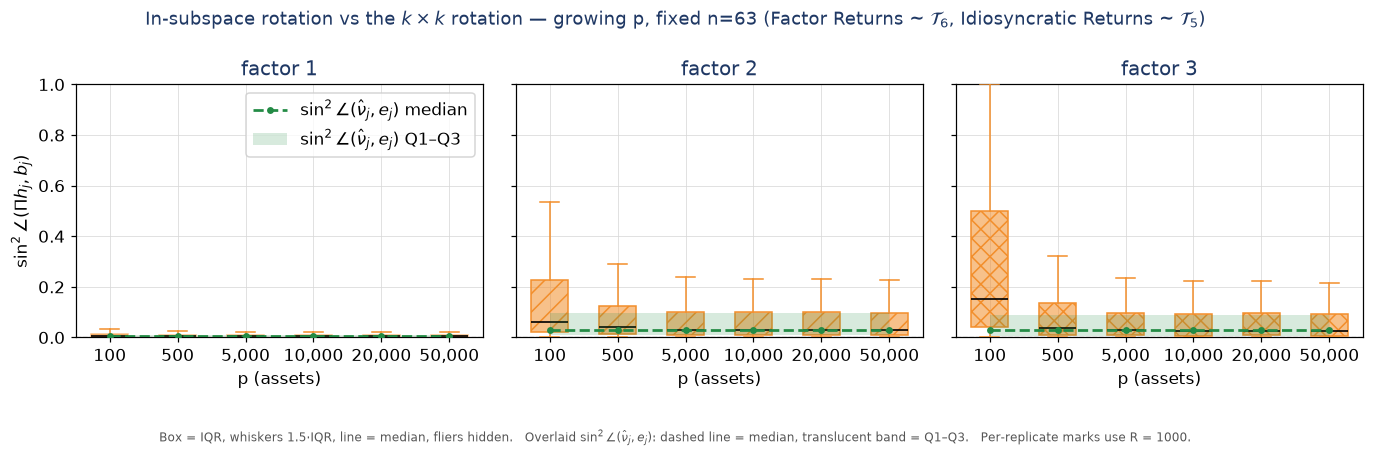

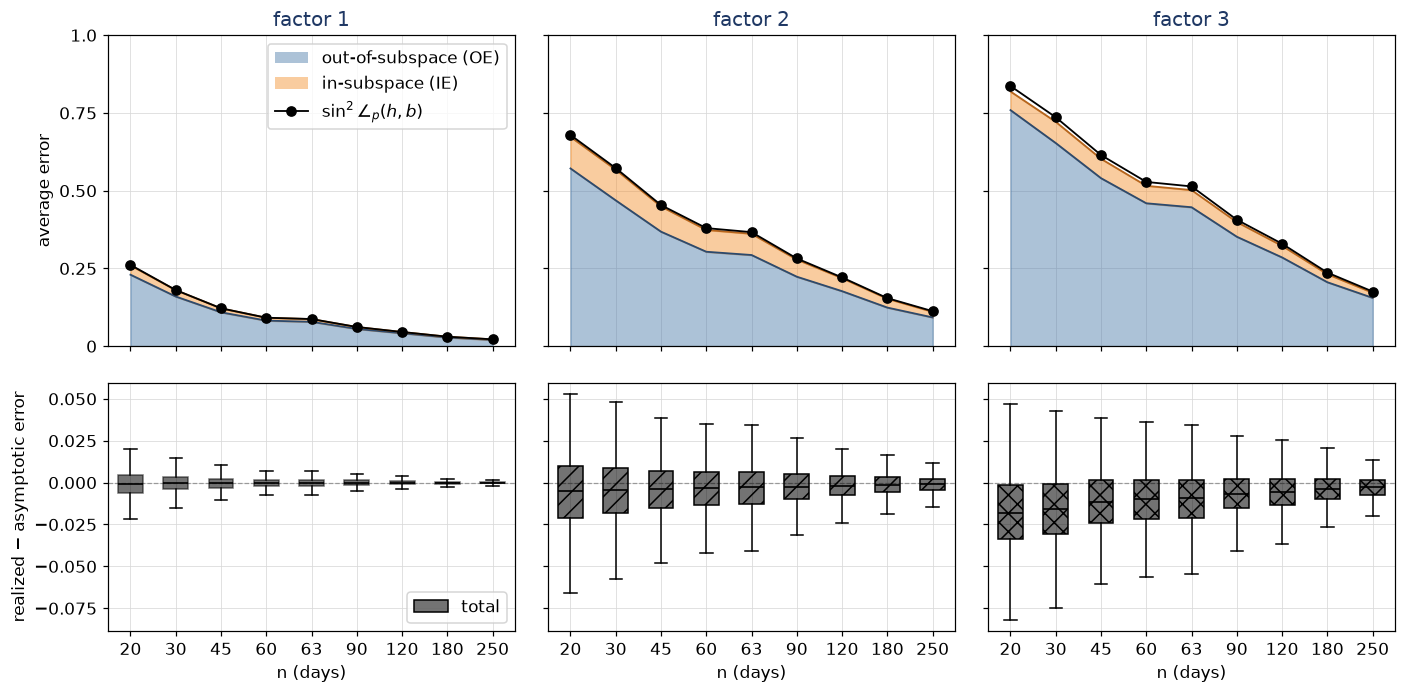

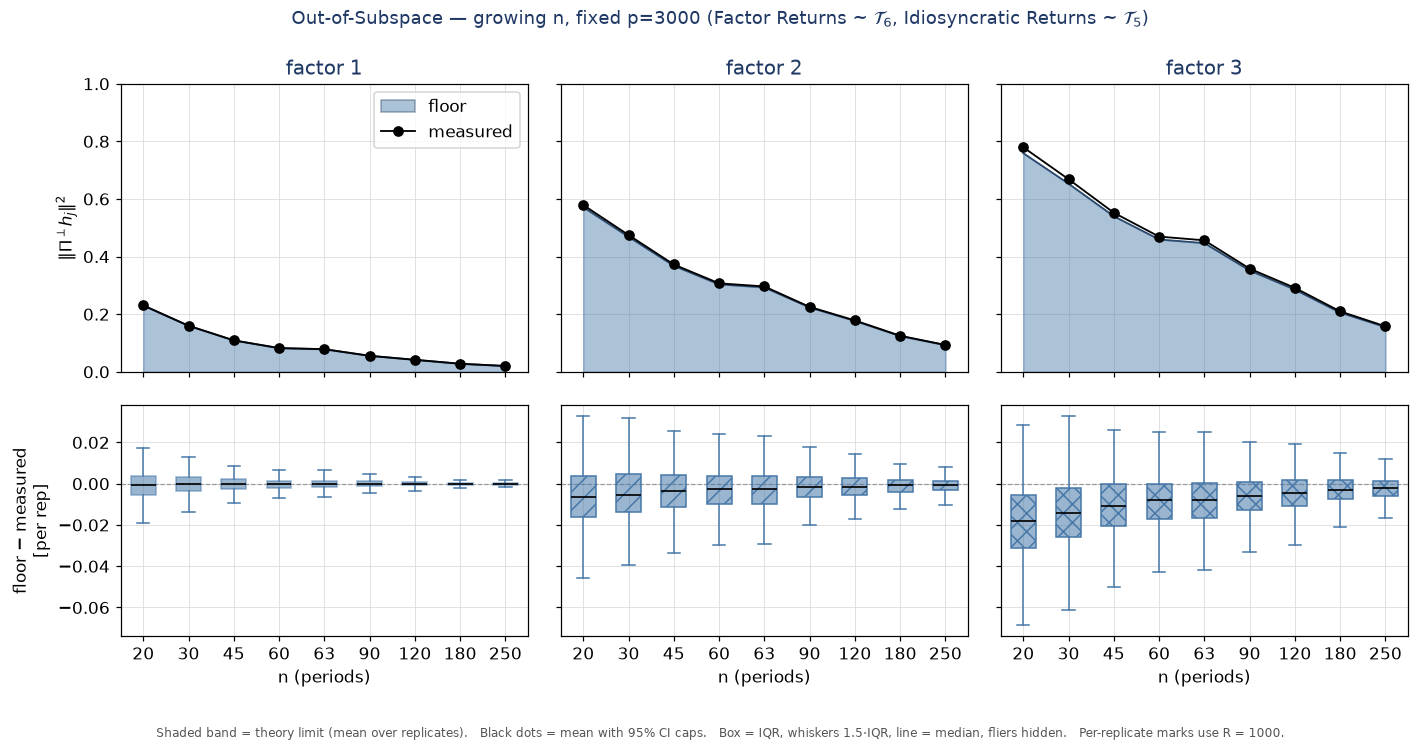

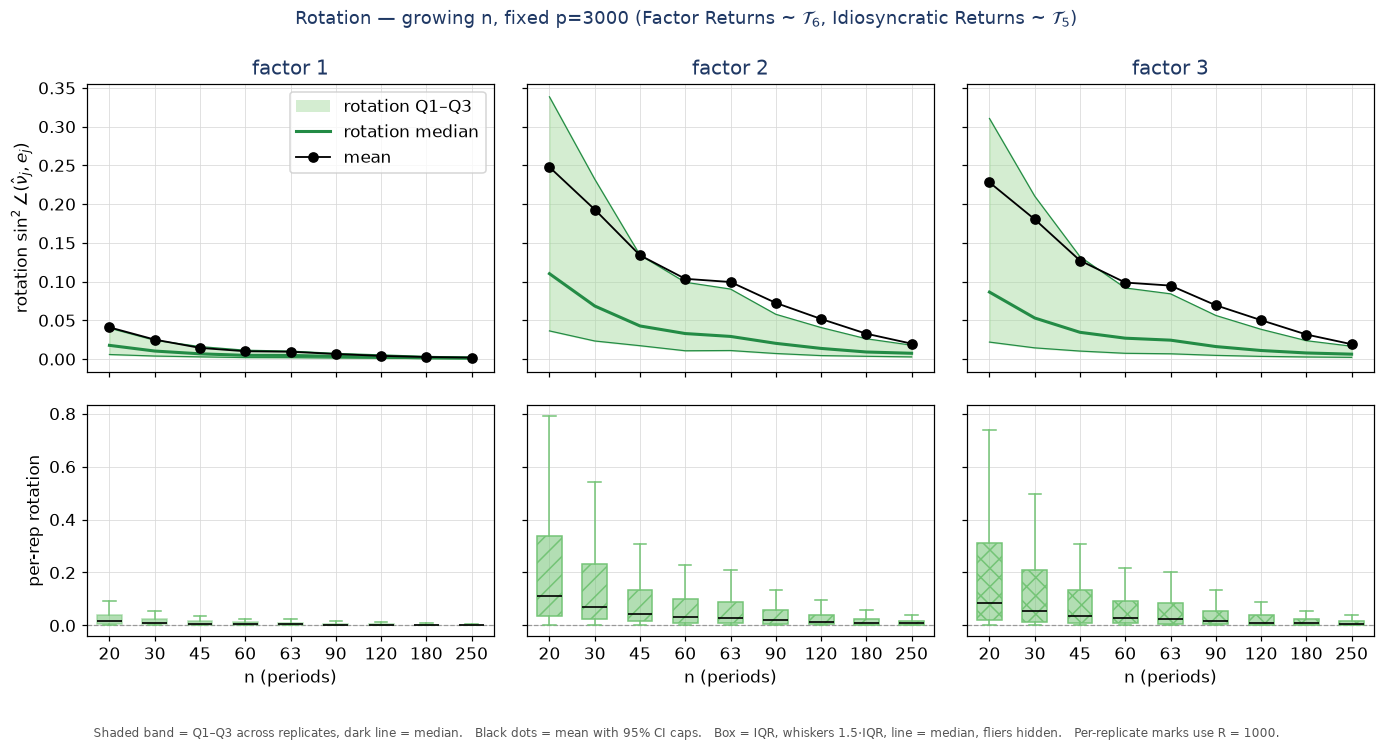

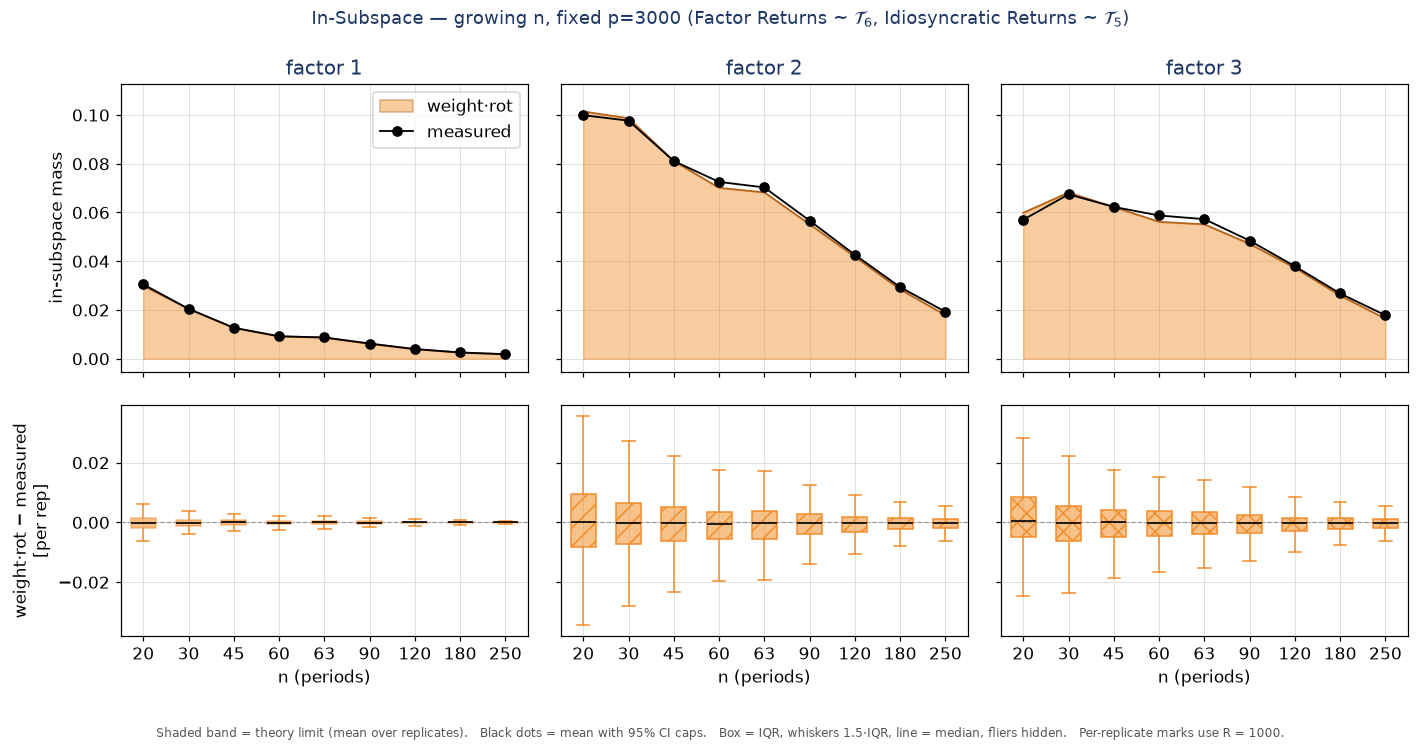

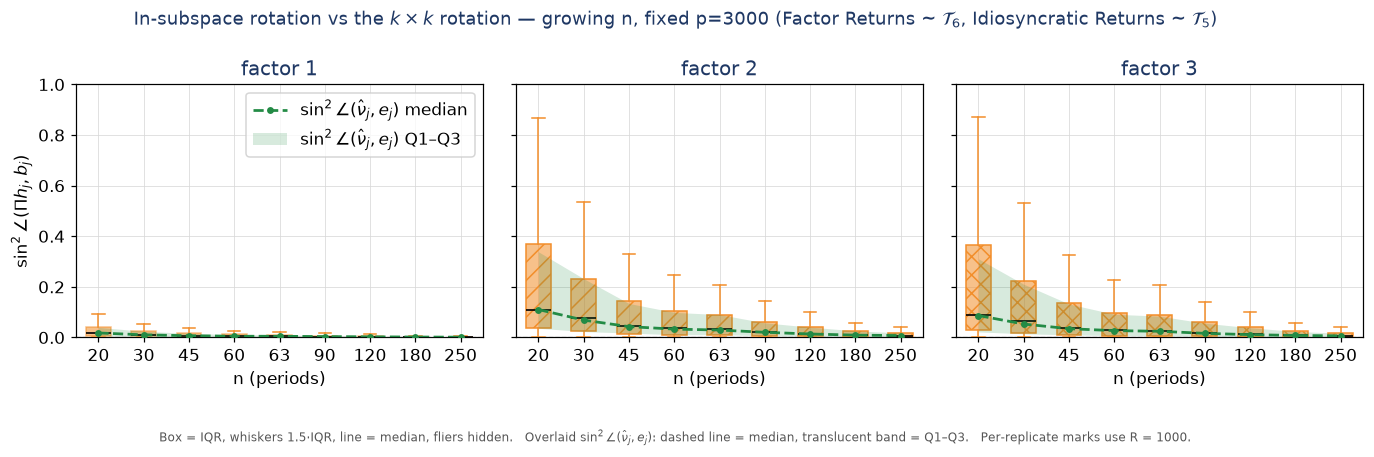

In [37]:
def comp_theme(color, cmap="Blues"):
    return Theme(factor_colors=(color,) * 6, factor_cmaps=(cmap,) * 6,
                 factor_hatches=FACTOR_HATCHES,
                 ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))

TOTAL_T = comp_theme("black")#comp_theme("#8c8c8c")
OOS_T = comp_theme("#4878a8")
ROT_T = comp_theme("#74c476", "Greens")
INSUB_T = comp_theme("#f28e2b", "Oranges")
ROT_FILL, ROT_LINE = "#a1d99b", "#238b45"

for d, key, lab in _SWEEPS:
    _out_path = out(f"comp1_total_{key}_qcolor", save=True)
    fig, axes = grid(d, key,
        rows=[Row(BandStack(labels=("out-of-subspace (OE)", "in-subspace (IE)",
                                    r"$\sin^2\angle_p(h,b)$")),
                  ylabel="average error", ylim=(0, 1),
                  yticks=THEME.sin2_ticks, height=1.0),
              Row(BoxDist("gap"), ylabel="realized − asymptotic error")],
        theme=TOTAL_T, #suptitle=rf"Total — {lab} {_TAILS}",
        caption=False,
        formats=FIG_FORMATS, out_path=None)
    if key == "n":
        for ax in axes[-1, :]:
            ax.set_xlabel("n (days)", fontsize=TOTAL_T.label_fontsize)
    import matplotlib.colors as mcolors
    from matplotlib.patches import Patch
    axes[1, 0].legend(
        handles=[Patch(facecolor=mcolors.to_rgba("black", 0.55),
                       edgecolor="black", label="total")],
        fontsize=TOTAL_T.legend_fontsize, loc="lower right")
    if _out_path is not None:
        for _ext in FIG_FORMATS:
            fig.savefig(str(_out_path) + f".{_ext}", dpi=150, bbox_inches="tight")
    show(fig)
    #### COMBINED PLOT
    fig, _ = grid(d, key,
        rows=[Row([Band("floor", label="floor"),
                   MeanCI("measured_out_of_subspace", label="measured")], ylim=(0,1),
                  ylabel=r"$\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
              Row(BoxDist("diff_oos"), ylabel="floor − measured\n[per rep]")],
        theme=OOS_T, suptitle=rf"Out-of-Subspace — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp2_oos_{key}_qcolor"))
    show(fig)

    #### ROTATION PLOT
    fig, _ = grid(d, key,
        rows=[Row([QuantileBand("rotation", label="rotation", fill=ROT_FILL, line=ROT_LINE),
                   MeanCI("rotation", label="mean")],
                  ylabel=r"rotation $\sin^2\angle(\hat\nu_j, e_j)$", height=1.0),
              Row(BoxDist("rotation"), ylabel="per-rep rotation")],
        theme=ROT_T, suptitle=rf"Rotation — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp3_rotation_{key}_qcolor"))
    show(fig)

    #### IN-SUBSPACE PLOT
    fig, _ = grid(d, key,
        rows=[Row([Band("theory_insub", label=r"weight$\cdot$rot",
                        fill=THEME.insub_fill, line=THEME.insub_line),
                   MeanCI("measured_in_subspace", label="measured")],
                  ylabel=r"in-subspace mass", height=1.0),
              Row(BoxDist("diff_insub"), ylabel="weight·rot − measured\n[per rep]")],
        theme=INSUB_T, suptitle=rf"In-Subspace — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_comp4_insub_{key}_qcolor"))
    show(fig)

    ##### IN-SUBSPACE ROTATION PLOT
    fig, _ = grid(d, key,
        rows=[Row([BoxDist("sin2_in"),
                   RefOverlay("rotation", label=r"$\sin^2\angle(\hat\nu_j, e_j)$",
                              color=ROT_LINE)],
                  ylabel=r"$\sin^2\angle(\Pi h_j, b_j)$", ylim=(0, 1), height=1.0)],
        sharey=True, theme=INSUB_T,
        suptitle=rf"In-subspace rotation vs the $k\times k$ rotation — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2v2_insub_rotation_{key}_qcolor"))
    show(fig)

---
## Change log

- **2026-08-13**: modern-API remake of the mono ex-2 v2 figure set — every figure composed
  from `fl_plot` marks (`BandStack`/`Band`/`MeanCI`/`QuantileBand`/`BoxDist`/`RefOverlay`),
  mono + component-colored sections, captions auto-assembled. Composition-only: data from
  the shared ex2v2 cache.